# Binary image classification (Cats vs Dogs) for a pet adoption platform

This notebook is used to perform:
- Data preparation, augmentation, 
- Train/val/test split
- Proofs of Concept (PoCs) of models - here, CNN model is used
- Hyperparameter tuning and model evaluation

## Environment Setup

Create and activate a Python virtual environment:

```powershell
# Create virtual environment
Python3.11 -m venv .venv

# Activate virtual environment (Windows PowerShell)
.\.venv\Scripts\Activate.ps1

# Upgrade package management tools
python -m pip install --upgrade pip setuptools wheel

# Install project dependencies
uv pip install -r requirements.txt
```

> **Note:** Ensure that `uv` is installed before running the last command. If not, install it using:
>
> ```powershell
> pip install uv
> ```

## Library imports

In [12]:
!pip install kaggle tensorflow scikit-learn matplotlib seaborn mlflow protobuf>=6.33.6

In [13]:
import os, shutil, zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print(tf.__version__)


2.20.0


## Kaggle Download

In [14]:
# import os
# import shutil

# kaggle_dir = os.path.join(os.environ['USERPROFILE'], '.kaggle')
# os.makedirs(kaggle_dir, exist_ok=True)
# print(f"Kaggle directory created at: {kaggle_dir}")

# !hutil.copy('../kaggle.json', os.path.join(kaggle_dir, 'kaggle.json'))
# !kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset

In [15]:
# import zipfile

# with zipfile.ZipFile("dog-and-cat-classification-dataset.zip", "r") as zip_ref:
#     zip_ref.extractall("dataset/Raw")

## Train/Validation/Test Split

Split into train/validation/test sets - 80%/10%/10%

In [ ]:
source_dir='../dataset/Raw/PetImages'
cats=[os.path.join(source_dir,'Cat',f) for f in os.listdir(os.path.join(source_dir,'Cat')) if f.endswith('.jpg')]
dogs=[os.path.join(source_dir,'Dog',f) for f in os.listdir(os.path.join(source_dir,'Dog')) if f.endswith('.jpg')]

# Set desired number of images per class
N = 1000
random.seed(42)
cats = random.sample(cats, min(N, len(cats)))
dogs = random.sample(dogs, min(N, len(dogs)))

images=cats+dogs
labels=[0]*len(cats)+[1]*len(dogs)
X_train,X_temp,y_train,y_temp=train_test_split(images,labels,test_size=0.2,stratify=labels,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5,stratify=y_temp,random_state=42)

In [17]:
base_dir='../dataset/Processed/cats_dogs_split'
for split in ['train','val','test']:
    for cls in ['cat','dog']:
        os.makedirs(os.path.join(base_dir,split,cls),exist_ok=True)

def copy_images(imgs,lbls,split):
    for img,l in zip(imgs,lbls):
        cls='cat' if l==0 else 'dog'
        try:
            shutil.copy(img, os.path.join(base_dir,split,cls,os.path.basename(img)))
        except:
            pass

copy_images(X_train,y_train,'train')
copy_images(X_val,y_val,'val')
copy_images(X_test,y_test,'test')

## Data Augmentation

Creating augmented data (via image generator) through morphological operations such as rotation, zoom, height width shifts, shear, flip for better generalization

In [18]:
IMG_SIZE=(224,224)
BATCH_SIZE=32
train_datagen=ImageDataGenerator(rescale=1./255,rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,shear_range=0.2,zoom_range=0.2,horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)

train_generator=train_datagen.flow_from_directory(os.path.join(base_dir,'train'),target_size=IMG_SIZE,batch_size=BATCH_SIZE,class_mode='binary')
val_generator=test_datagen.flow_from_directory(os.path.join(base_dir,'val'),target_size=IMG_SIZE,batch_size=BATCH_SIZE,class_mode='binary')
test_generator=test_datagen.flow_from_directory(os.path.join(base_dir,'test'),target_size=IMG_SIZE,batch_size=BATCH_SIZE,class_mode='binary',shuffle=False)

Found 8696 images belonging to 2 classes.
Found 1183 images belonging to 2 classes.
Found 1186 images belonging to 2 classes.


## CNN Model

In [19]:
model=models.Sequential([
layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
layers.MaxPooling2D(2,2),
layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),
layers.Conv2D(128,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),
layers.Conv2D(256,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),
layers.Flatten(),
layers.Dense(512,activation='relu'),
layers.Dropout(0.5),
layers.Dense(1,activation='sigmoid')])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

c:\Users\naras\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,263,809 (73.49 MB)

 Trainable params: 19,263,809 (73.49 MB)

 Non-trainable params: 0 (0.00 B)

## Training with MLFlow

After training, you can launch the MLflow UI with: mlflow ui --backend-store-uri sqlite:///mlflow.db

In [ ]:
import mlflow
import mlflow.tensorflow
from mlflow.models import infer_signature

mlflow.set_tracking_uri("sqlite:///mlflow.db")

mlflow.set_experiment('Cats_Dogs_CNN')

print("MLflow Tracking URI:", mlflow.get_tracking_uri())

with mlflow.start_run(run_name='CNN_Training'):
    # Log model/training parameters
    mlflow.log_params({
        'img_size': str(IMG_SIZE),
        'batch_size': BATCH_SIZE,
        'epochs': 5,
        'optimizer': 'adam',
        'loss': 'binary_crossentropy',
        'augmentation': True,
        'rotation_range': 20,
        'width_shift_range': 0.2,
        'height_shift_range': 0.2,
        'shear_range': 0.2,
        'zoom_range': 0.2,
        'horizontal_flip': True
    })

    history=model.fit(train_generator, validation_data=val_generator, epochs=5)

    # Log metrics for every epoch
    for epoch, (loss, acc, val_loss, val_acc) in enumerate(zip(
        history.history['loss'], history.history['accuracy'],
        history.history['val_loss'], history.history['val_accuracy'])):
        mlflow.log_metrics({
            'train_loss': loss,
            'train_accuracy': acc,
            'val_loss': val_loss,
            'val_accuracy': val_acc
        }, step=epoch)

    # Evaluate on the held-out test set and log final metrics
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    mlflow.log_metrics({'test_loss': test_loss, 'test_accuracy': test_acc})

    # Save and log the trained model as an MLflow artifact
    model_path = '../serving/model/cats_dogs_cnn.keras'
    model.save(model_path)
    mlflow.log_artifact(model_path)

    # Log the TensorFlow/Keras model in MLflow's model format
    signature = infer_signature(np.zeros((1, 224, 224, 3), dtype=np.float32), model.predict(np.zeros((1, 224, 224, 3), dtype=np.float32), verbose=0))
    mlflow.tensorflow.log_model(model, name='cnn_model', signature=signature)

    print('Test Accuracy:', test_acc)
    print('MLflow Run ID:', mlflow.active_run().info.run_id)


MLflow Tracking URI: sqlite:///mlflow.db


Epoch 1/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.5284 - loss: 0.6932 - val_accuracy: 0.5207 - val_loss: 0.6907
Epoch 2/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 207s 756ms/step - accuracy: 0.5681 - loss: 0.6836 - val_accuracy: 0.6331 - val_loss: 0.6535
Epoch 3/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 184s 676ms/step - accuracy: 0.5942 - loss: 0.6642 - val_accuracy: 0.6492 - val_loss: 0.6353
Epoch 4/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 167s 611ms/step - accuracy: 0.6336 - loss: 0.6414 - val_accuracy: 0.6813 - val_loss: 0.6073
Epoch 5/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 233s 856ms/step - accuracy: 0.6617 - loss: 0.6198 - val_accuracy: 0.6915 - val_loss: 0.5872
38/38 ━━━━━━━━━━━━━━━━━━━━ 24s 651ms/step - accuracy: 0.6737 - loss: 0.5783
Test Accuracy: 0.673693060874939
MLflow Run ID: b700039e22e441e7bb26b27a6f1c9d64


## Model Prediction

In [21]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

MODEL_PATH = './model/cats_dogs_cnn.keras'
model = load_model(MODEL_PATH)
print('Model loaded successfully.')

Model loaded successfully.


In [22]:
def predict_cat_or_dog(image_path: str):
    """Predict whether an input image is a cat or a dog."""
    IMG_SIZE = (224, 224)

    image = load_img(image_path, target_size=IMG_SIZE)
    image_array = img_to_array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    # Sigmoid output represents the probability of the dog class.
    dog_probability = float(model.predict(image_array, verbose=0)[0][0])

    if dog_probability >= 0.5:
        label = 'Dog'
        confidence = dog_probability
    else:
        label = 'Cat'
        confidence = 1.0 - dog_probability

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Prediction: {label} ({confidence * 100:.2f}%)')
    plt.show()

    print(f'Prediction: {label}')
    print(f'Confidence: {confidence * 100:.2f}%')
    print(f'Dog probability: {dog_probability * 100:.2f}%')

    return label, confidence

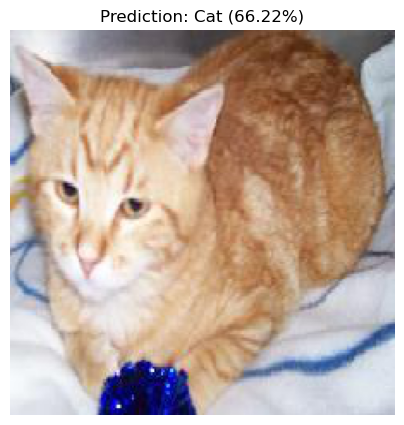

Prediction: Cat
Confidence: 66.22%
Dog probability: 33.78%


('Cat', 0.6622417569160461)

In [25]:
# Example using an image from the test dataset:
image_path = r'../dataset/Processed/cats_dogs_split/test/cat/42.jpg'

predict_cat_or_dog(image_path)

## Interative application

Using Gradio to create a UI for the prediction

In [ ]:
import os
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import img_to_array

# ==============================
# Configuration
# ==============================
MODEL_PATH = "./model/cats_dogs_cnn.keras"
IMG_SIZE = (224, 224)

# Load model once when the application starts
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found: {MODEL_PATH}. "
        "Make sure cats_dogs_cnn.keras is inside the model directory."
    )

model = load_model(MODEL_PATH)


# ==============================
# Prediction Function
# ==============================
def predict_cat_or_dog(image):
    """Predict whether the uploaded image is a cat or a dog."""

    if image is None:
        return "Please upload an image.", None

    # Resize image to the same size used during training
    image = image.resize(IMG_SIZE)

    # Convert to NumPy array
    image_array = img_to_array(image)

    # Ensure RGB input
    if image_array.shape[-1] == 4:
        image_array = image_array[:, :, :3]

    # Normalize
    image_array = image_array / 255.0

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Model prediction
    dog_probability = float(
        model.predict(image_array, verbose=0)[0][0]
    )

    cat_probability = 1.0 - dog_probability

    if dog_probability >= 0.5:
        label = "Dog"
        confidence = dog_probability
    else:
        label = "Cat"
        confidence = cat_probability

    result = (
        f"Prediction: {label}\n"
        f"Confidence: {confidence * 100:.2f}%\n\n"
        f"Cat: {cat_probability * 100:.2f}%\n"
        f"Dog: {dog_probability * 100:.2f}%"
    )

    probabilities = {
        "Cat": cat_probability,
        "Dog": dog_probability
    }

    return result, probabilities


# ==============================
# Gradio UI
# ==============================
with gr.Blocks(title="Cats vs Dogs Classifier") as demo:

    gr.Markdown(
        """
        # 🐱🐶 Cats vs Dogs Classifier

        Upload an image and the trained CNN model will predict whether
        it contains a **Cat** or **Dog**.
        """
    )

    with gr.Row():

        with gr.Column():
            image_input = gr.Image(
                type="pil",
                label="Upload Image"
            )

            predict_button = gr.Button(
                "Predict",
                variant="primary"
            )

        with gr.Column():
            prediction_output = gr.Textbox(
                label="Prediction",
                lines=5
            )

            probability_output = gr.Label(
                label="Class Probabilities"
            )

    predict_button.click(
        fn=predict_cat_or_dog,
        inputs=image_input,
        outputs=[
            prediction_output,
            probability_output
        ]
    )

    gr.Markdown(
        """
        **Model:** CNN  
        **Input size:** 224 × 224 RGB  
        **Classes:** Cat / Dog
        """
    )


# ==============================
# Launch Application
# ==============================
if __name__ == "__main__":
    demo.launch()
